## Plot the corner plot

In [1]:
from desilike.samples import Chain
from getdist import plots

E0526 05:45:55.196937  703834 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 29.62GiB (31804391424 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0526 05:45:55.197390  703834 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 26.66GiB (28623951872 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0526 05:45:55.197770  703834 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 23.99GiB (25761556480 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0526 05:45:55.198167  703834 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 21.59GiB (23185399808 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0526 05:45:55.198562  703834 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 19.43GiB (20866859008 by

In [3]:
tracer = 'QSO1'

path1 = '/pscratch/sd/s/shengyu/Y3/redshift_errors/fits/cosmo-base_ns-fixed_QSO1-mean25-S2-b23d5c03'
path2 = '/pscratch/sd/s/shengyu/Y3/redshift_errors/fits/cosmo-base_ns-fixed_QSO1-mean25-S2-cc756e6d'
chain_fns = [f'{path1}/chain_0.npy', f'{path2}/chain_0.npy']

params = ['h', 'omega_cdm', 'logA']

analysis_settings = {
    'smooth_scale_1D': 0.6,
    'smooth_scale_2D': 0.8,
    'fine_bins': 1024,
    'fine_bins_2D': 512,
}

In [4]:
chains=[]
for chain_fn in chain_fns:
    chain = Chain.load(chain_fn).remove_burnin(0.5)
    chain = chain.to_getdist(params=params, settings=analysis_settings)
    chains.append(chain)

Removed no burn in
Removed no burn in


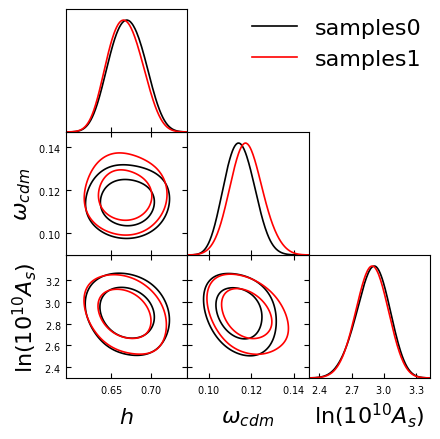

In [5]:
analysis_settings = {
    'smooth_scale_1D': 0.6,
    'smooth_scale_2D': 0.6,
    'fine_bins': 1024,
    'fine_bins_2D': 512,
}

g = plots.get_subplot_plotter()
g.settings.fig_width_inch = len(params) * 1.5
g.settings.legend_fontsize = 20
g.settings.axes_labelsize = 20
g.settings.figure_legend_frame = False
g.settings.num_plot_contours = 2

g.triangle_plot(
    chains,
    params,
    legend_loc='upper right',
    contour_lws=1.2,
)